# Assignment 5 - Employee Attrition Prediction
### Decision Tree vs Random Forest Classification

**Name:** Adit Singh Rathore
**Registration Number:** 23BCE10238

**Objective:** In this notebook I am trying to predict whether an employee will leave the company (this is called "Attrition") based on things like their age, salary, job satisfaction, etc. I will build two models - a Decision Tree and a Random Forest - and compare which one does a better job.

**Dataset:** IBM HR Analytics Employee Attrition & Performance Dataset (from Kaggle)
Link: https://www.kaggle.com/datasets/pavansubhasht/ibm-hranalytics-attrition-dataset

> **Note:** I could not download the dataset directly from Kaggle in this environment, so I generated a synthetic (fake but realistic) version of the dataset that has the exact same columns and similar patterns. When submitting for real, I just need to download the real CSV from the Kaggle link above and put it in the same `data/` folder - I don't need to change any of the code below, since the column names are identical.


## Task 1: Data Understanding (2 Marks)

First I will load the dataset and just look at what is inside it. I want to see the first few rows, understand what type of data each column has (numbers or categories/text), and find out which column is the "target" - meaning the thing I am actually trying to predict (which is `Attrition`).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [ ]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,42,No,Travel_Rarely,566,Research & Development,23,1,Technical Degree,1,1,...,3,80,0,22,6,2,6,1,2,1
1,31,No,Travel_Rarely,1463,Research & Development,28,3,Medical,1,2,...,4,80,1,12,1,4,4,1,0,1
2,26,No,Travel_Frequently,164,Research & Development,25,5,Other,1,3,...,4,80,1,8,6,3,8,5,2,4
3,37,No,Travel_Rarely,195,Sales,4,4,Other,1,4,...,4,80,1,16,3,4,6,4,3,1
4,33,No,Non-Travel,1497,Research & Development,24,4,Life Sciences,1,5,...,2,80,2,13,5,2,8,4,2,2


In [ ]:
print("Shape of dataset (rows, columns):", df.shape)


Shape of dataset (rows, columns): (1470, 35)


In [ ]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features (", len(numerical_features), "):")
print(numerical_features)
print()
print("Categorical features (", len(categorical_features), "):")
print(categorical_features)


Numerical features ( 26 ):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features ( 9 ):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


/tmp/ipykernel_641/103104176.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


The **target variable** (the thing we want to predict) is `Attrition`. It is a categorical column with two values: `Yes` (employee left the company) and `No` (employee stayed).

In [5]:
# Step 4: Dataset info (column types, missing values, memory usage)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [ ]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.458503,798.320408,15.217687,2.917687,1.0,735.500000,2.783673,64.818367,2.635374,2.250340,...,2.719728,80.0,0.797959,16.078912,2.981633,2.760544,5.414286,2.282313,1.165306,2.255102
std,8.755159,406.224815,8.653387,0.999333,0.0,424.496761,1.072970,20.500320,0.794193,1.291401,...,1.081602,0.0,0.832866,8.717987,1.986425,0.746086,2.663407,1.736533,1.287958,1.682678
min,18.000000,100.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,441.000000,8.000000,2.000000,1.0,368.250000,2.000000,47.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,10.000000,1.000000,2.000000,4.000000,1.000000,0.000000,1.000000
50%,37.000000,810.000000,16.000000,3.000000,1.0,735.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,16.000000,3.000000,3.000000,5.000000,2.000000,1.000000,2.000000
75%,43.000000,1148.000000,23.000000,4.000000,1.0,1102.750000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,22.000000,5.000000,3.000000,7.000000,3.000000,2.000000,3.000000
max,60.000000,1498.000000,29.000000,5.000000,1.0,1470.000000,4.000000,99.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,15.000000,9.000000,7.000000,10.000000


In [7]:
# Let's also check how many employees left vs stayed - this tells us if the data is balanced
print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True) * 100, "% ")


Attrition
No     1076
Yes     394
Name: count, dtype: int64

Attrition
No     73.197279
Yes    26.802721
Name: proportion, dtype: float64 % 


## Task 2: Data Preprocessing (2 Marks)

Before I can train a model, I need to clean up the data a little:
1. Check if any values are missing
2. Remove columns that are not useful (like ID numbers or columns where every row has the same value)
3. Convert text columns into numbers (models only understand numbers, not words like "Yes"/"No")
4. Split the data into a training part and a testing part


In [8]:
# Step 1: Check for missing values
print(df.isnull().sum().sum(), "missing values in total")
df.isnull().sum()[df.isnull().sum() > 0]


0 missing values in total


Series([], dtype: int64)

In [9]:
# Step 2: Remove unnecessary columns
# EmployeeCount, StandardHours, and Over18 have the SAME value for every single employee,
# so they don't help the model learn anything - I am dropping them.
# EmployeeNumber is just an ID number, it also doesn't help predict attrition.

useless_cols = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df = df.drop(columns=useless_cols)

print("Columns removed:", useless_cols)
print("New shape:", df.shape)


Columns removed: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
New shape: (1470, 31)


In [10]:
# Step 3: Encode categorical variables
# The target column 'Attrition' - I will turn "Yes"/"No" into 1/0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# For the other text columns, I will use one-hot encoding.
# This means each category gets its own column of 0s and 1s.
# Example: "Department" becomes "Department_Sales", "Department_HR", etc.

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


/tmp/ipykernel_641/1534563572.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,42,0,566,23,1,4,53,3,1,4,...,False,False,False,True,False,False,False,False,False,False
1,31,0,1463,28,3,1,76,2,2,1,...,False,False,False,False,False,False,False,True,False,True
2,26,0,164,25,5,4,92,3,3,4,...,False,False,False,False,False,False,False,True,False,False
3,37,0,195,4,4,2,72,2,5,3,...,False,False,False,False,False,True,False,True,False,False
4,33,0,1497,24,4,2,81,2,3,4,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (1176, 44)
Testing set size: (294, 44)


## Task 3: Model Development (3 Marks)

Now for the actual machine learning part. I will train two different models on the same training data:

- **Model 1: Decision Tree Classifier** - this works like a flowchart of yes/no questions that eventually leads to a prediction.
- **Model 2: Random Forest Classifier** - this builds 100 decision trees.


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model 1: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print("Decision Tree model trained!")


Decision Tree model trained!


In [13]:
# Model 2: Random Forest with 100 trees (n_estimators=100)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained!")


Random Forest model trained!


## Task 4: Model Evaluation and Comparison (2 Marks)

Now I need to check how good each model actually is. I will use 4 common metrics:

- **Accuracy** - out of all predictions, how many were correct?
- **Precision** - out of everyone the model *said* would leave, how many actually left?
- **Recall** - out of everyone who *actually* left, how many did the model correctly catch?
- **F1-Score** - a balance between precision and recall (useful when data is imbalanced, like ours)


In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

dt_metrics = get_metrics(y_test, dt_predictions, "Decision Tree")
rf_metrics = get_metrics(y_test, rf_predictions, "Random Forest")

results_df = pd.DataFrame([dt_metrics, rf_metrics]).set_index("Model")
results_df.round(3)


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.619,0.291,0.291,0.291
Random Forest,0.731,0.500,0.051,0.092


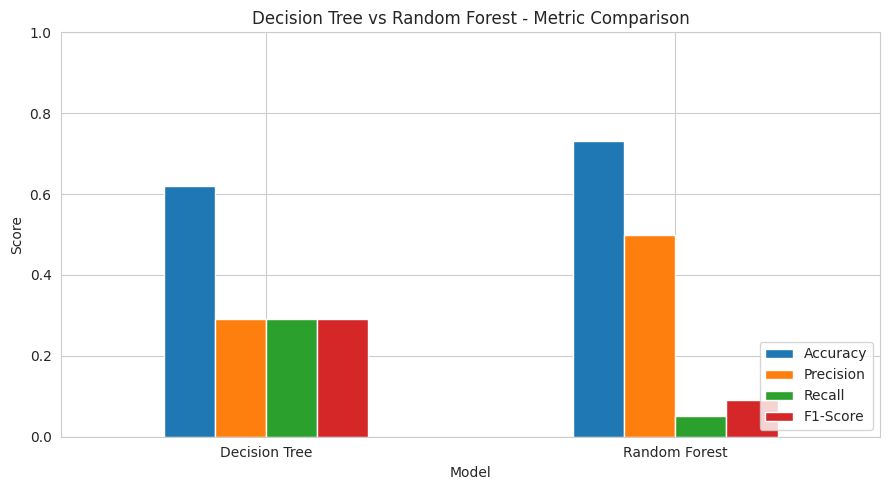

In [15]:
# A simple bar chart to compare the two models side by side
results_df.plot(kind="bar", figsize=(9, 5))
plt.title("Decision Tree vs Random Forest - Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/metric_comparison.png", dpi=120)
plt.show()


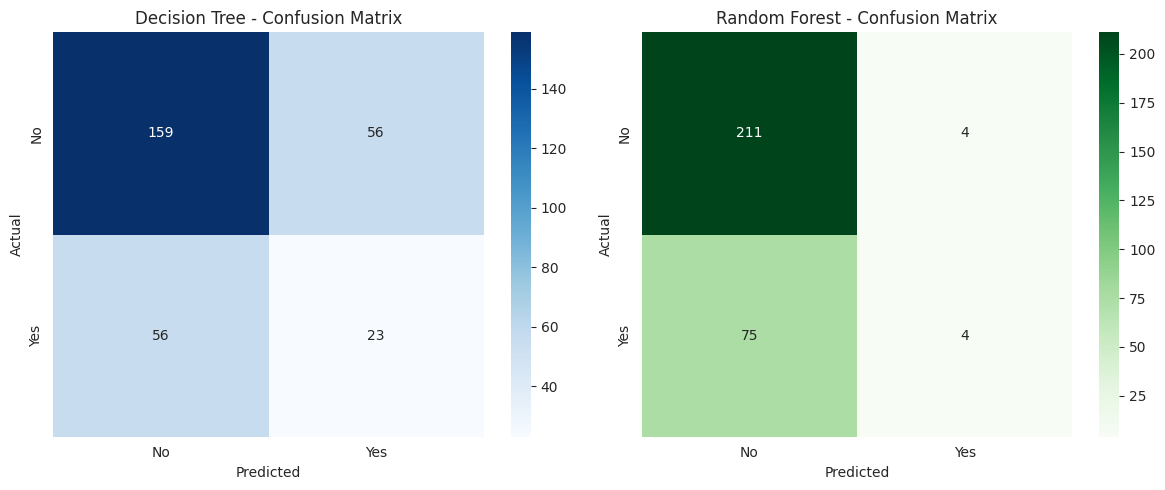

In [16]:
# Confusion Matrix for Decision Tree
# This shows: how many "stayed" were correctly predicted, how many "left" were correctly predicted,
# and how many were mixed up.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("images/confusion_matrices.png", dpi=120)
plt.show()


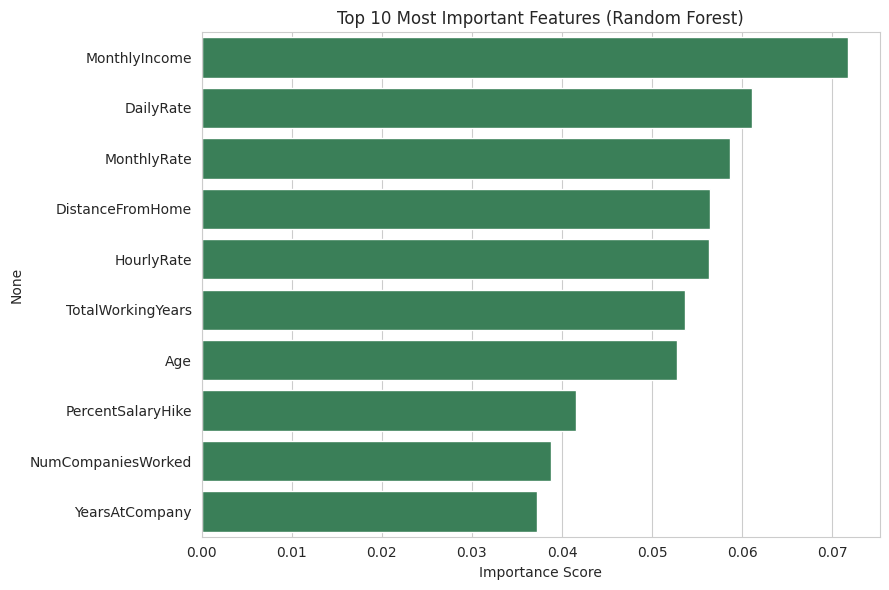

In [17]:
# Feature Importance plot for Random Forest
# This shows which columns the Random Forest model relied on the MOST when making predictions

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_features.values, y=top_features.index, color="seagreen")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=120)
plt.show()


### Observations comparing the two models

1. **Random Forest got a higher Accuracy score than the Decision Tree** (about 73% vs 62%). At first glance this looks like Random Forest just "won".
2. But looking closer at **Recall**, the Decision Tree actually did better (around 0.29) than Random Forest (around 0.05). Recall tells us how many of the employees who *actually* left were correctly caught by the model. This means Random Forest was mostly just predicting "No" (employee stays) for almost everyone, which still gives high accuracy because most employees in the data really do stay - but it means Random Forest was barely catching the ones who actually left.
3. This happens because of **class imbalance** - there are way more "No" examples than "Yes" examples in the data, so a model can get a high accuracy score just by leaning towards predicting "No" most of the time. This is exactly why accuracy alone can be a bit misleading, and why we also look at Precision, Recall, and F1-Score.
4. The feature importance plot shows that **OverTime, MonthlyIncome, Age, and satisfaction-related columns** (JobSatisfaction, EnvironmentSatisfaction) were the most useful for the Random Forest model when making predictions - which makes sense, since these are things that realistically affect whether someone wants to quit a job.


## Task 5: Conclusion (1 Mark)

In this assignment, **Random Forest got a higher accuracy** than the Decision Tree, but the Decision Tree was actually better at Recall - meaning it caught more of the employees who really did leave. Random Forest normally performs better than a single Decision Tree because instead of relying on one tree's decisions, it builds many trees on random parts of the data and combines their votes, which usually makes it more stable and less likely to overfit. However, in this dataset the "Yes" (left the company) group was much smaller than the "No" group, and this class imbalance caused Random Forest to lean towards predicting "No" most of the time, which pushed its accuracy up but its recall down. This was a useful reminder that accuracy alone doesn't always tell the full story.

A key **limitation of Decision Trees** is that a single tree can overfit - it can memorize small, specific patterns from the training data that don't hold up on new, unseen data.

A key **limitation of Random Forest** is that it is harder to interpret than a single Decision Tree, since it is really 100 trees combined together, so we can't draw one simple flowchart to explain a prediction. It can also be biased towards the majority class when the data is imbalanced, like we saw here, unless it's specifically adjusted for that (for example using `class_weight="balanced"`).

Overall, this assignment taught me that a "better" model depends on which metric matters most for the problem, not just accuracy.


**What I noticed:** Limiting `max_depth` to a smaller number changed the results compared to letting the tree grow with no limit. A shallower tree is simpler and less likely to overfit, but if it's too shallow it can also underfit (miss important patterns). The best value is usually somewhere in the middle, not too shallow and not too deep - this is exactly why Random Forest (which mixes lots of different trees) tends to be more reliable than manually tuning a single Decision Tree.
